# Markov Chain Model for Tomimoto and Satake 2026
Following is the code for calculating inter-branch SNVs by the Markov chain model, and for model fitting by ABC-SMC.  

##### Packages information used in this code:  
numpy==2.0.1  
pyabc==0.12.15  
scipy==1.15.3  
seaborn==0.13.2  
matplotlib==3.10.0 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import math
from scipy.stats import binom # structured elongation
from scipy.stats import hypergeom # stochastic elongation

import itertools # pattern of mutation expansion
import copy

### Transition matrices

In [3]:
# Elongation

def el_str_M(num_stem, mut_rate): # structured elongation transition matrix
    
    tr_matrix = np.zeros((num_stem+1, num_stem+1))
    
    for i in range(num_stem+1):
        for j in range(num_stem+1):
            
            tr_matrix[i, j] = binom.pmf(j-i, num_stem-i, mut_rate)

    return tr_matrix

def el_sto_M(num_stem, mut_rate): # stochastic elongation transition matrix
    
    tr_matrix = np.zeros((num_stem+1, num_stem+1))
    
    for i in range(num_stem+1):
        for j in range(num_stem+1):
            
            #print(sum([m for m in range(2*(num_stem-i)+1)]))
            tr_matrix[i, j] = sum([ binom.pmf(m, 2*(num_stem-i), mut_rate)
                                   *hypergeom.pmf(j, 2*num_stem, 2*i+m, num_stem) for m in range(2*(num_stem-i)+1)])

    return tr_matrix

In [4]:
# Branching

def br_wf_M(num_stem): # wright-fisher Branching transition matrix
    
    tr_matrix = np.zeros((num_stem+1, num_stem+1))
    
    for i in range(num_stem+1):
        for j in range(num_stem+1):

            tr_matrix[i, j] = binom.pmf(j, num_stem, i/num_stem)

    return tr_matrix

def br_sc_M(num_stem): # single cell Branching transition matrix
    
    tr_matrix = np.zeros((num_stem+1, num_stem+1))
    
    for i in range(num_stem+1):
        for j in range(num_stem+1):

            if j == 0:
                tr_matrix[i, j] = (num_stem-i)/num_stem
            elif j == num_stem:
                tr_matrix[i, j] = i/num_stem
            else:
                tr_matrix[i, j] = 0

    return tr_matrix

In [5]:
def state_V(num_stem): # state vector
    
    stateVector = np.zeros(num_stem+1, dtype=float) # state vectore
    stateVector[0] = 1
    
    return stateVector

def mat_pw(mat_, t_): # power of matrix
    
    return np.linalg.matrix_power(mat_, t_)

def initial_state(num_stem, i_): # state vector
    
    stateVector = np.zeros(num_stem+1, dtype=float) # state vectore
    stateVector[i_] = 1
    
    return stateVector

def inter_branch_f(mat_i, mat_j): # average distance
    
    num_stem = len(mat_i)-1
    
    tes1 = mat_i
    tes2 = mat_j

    tes1_list = []
    tes2_list = []
    
    for i in range(num_stem+1):
        
        tes1_v = initial_state(num_stem, i)@tes1
        tes2_v = initial_state(num_stem, i)@tes2
        
        mean_1 = np.sum([kct*k for kct, k in enumerate(tes1_v)]) # mean of the state vector
        mean_2 = np.sum([kct*k for kct, k in enumerate(tes2_v)]) # --

        tes1_list.append(mean_1)
        tes2_list.append(mean_2)

    tes_list = []
    
    for j in range(num_stem+1):
    
        tes_list.append( tes1_list[j]/num_stem *(1-tes2_list[j]/num_stem) + (1-tes1_list[j]/num_stem)*tes2_list[j]/num_stem )
    
    return np.array(tes_list)

### Calculating inter-branch SNVs

In [6]:
# function: inter-branch mutation by Markov chain

def ibm_Markov(num_stem, mu_, div_, dyn_, brlist_):
    """　Func for Exp. of Inter-branch mutations by Markov chain
    Args:
        num_stem    (int): Num of stem cells in meristem.
        mu_       (float): Rate of mutation per cell per meter
        div_      (float): Number of cell divisions per meter
        dyn_        (int): Dynamics of stem cells (1-> stru+unbias, 2-> stru+bias, 3-> stoc+unbias, 4-> stoc+bias)
        brlist_ (ndarray): List of branch length
    
    Return:
        [z_Flat, d_Flat, api_Flat] (list): Exp. of inter-branch mutation, Distance between branches, Apical states
    
    Note:
    """
    
    # given parameters
    numBranch = 7
    br_ID = ['11','10','21','20','31','30','40']

    µ_ = mu_ /div_

    s0_0 = round(brlist_[0] *div_)
    s0_1 = round(brlist_[1] *div_)
    s0_2 = round(brlist_[2] *div_)
    s0_3 = round(brlist_[3] *div_)

    b10_0 = round(brlist_[4] *div_)
    b10_1 = round(brlist_[5] *div_) 
    b11   = round(brlist_[6] *div_)

    b20_0 = round(brlist_[7] *div_)
    b20_1 = round(brlist_[8] *div_)
    b21   = round(brlist_[9] *div_)

    b30_0 = round(brlist_[10] *div_)
    b30_1 = round(brlist_[11] *div_)
    b31   = round(brlist_[12] *div_)
    
    brTimeMatrix = np.array([[0, b10_1+b11, b11+b10_0+s0_1+b20_0+b21, b11+b10_0+s0_1+b20_0+b20_1, b11+b10_0+s0_1+s0_2+b30_0+b31, b11+b10_0+s0_1+s0_2+b30_0+b30_1, s0_3+s0_2+s0_1+b10_0+b11],
                         [0,0, b10_1+b10_0+s0_1+b20_0+b21, b10_1+b10_0+s0_1+b20_0+b20_1, b10_1+b10_0+s0_1+s0_2+b30_0+b31, b10_1+b10_0+s0_1+s0_2+b30_0+b30_1, s0_3+s0_2+s0_1+b10_0+b10_1],
                         [0,0,0, b21+b20_1, b21+b20_0+s0_2+b30_0+b31, b21+b20_0+s0_2+b30_0+b30_1, s0_3+s0_2+b20_0+b21], 
                         [0,0,0,0, b20_1+b20_0+s0_2+b30_0+b31, b20_1+b20_0+s0_2+b30_0+b30_1, s0_3+s0_2+b20_0+b20_1], 
                         [0,0,0,0,0, b30_1+b31, s0_3+b30_0+b31],
                         [0,0,0,0,0,0, s0_3+b30_0+b30_1], 
                         [0,0,0,0,0,0,0]])

    #brTimeSet = sorted(set(brTimeMatrix.flatten())) # Set of lenght in order

    for kcut,k in enumerate(brTimeMatrix):
        for lcut,l in enumerate(brTimeMatrix):
            if kcut > lcut:
                brTimeMatrix[kcut][lcut]= l[kcut]

    # apical(0) non-apical(1) matrix
    api_M = np.array([[0, 0, 1, 1, 1, 1, 0],
                      [0, 0, 1, 1, 1, 1, 0],
                      [1, 1, 0, 0, 1, 1, 0],
                      [1, 1, 0, 0, 1, 1, 0],
                      [1, 1, 1, 1, 0, 0, 0],
                      [1, 1, 1, 1, 0, 0, 0],
                      [0, 0, 0, 0, 0, 0, 0]])
    
    # caululation of matrix ----------------------------------------------------------

    # transition matrix
    st_V = state_V(num_stem)

    if dyn_ == 1:
        el_Mat = el_str_M(num_stem, µ_) # structured
        br_Mat = br_wf_M(num_stem) # wright-fisher
        
    elif dyn_ == 2:
        el_Mat = el_str_M(num_stem, µ_) # structured
        br_Mat = br_sc_M(num_stem) # single cell
        
    elif dyn_ == 3:
        el_Mat = el_sto_M(num_stem, µ_) # stochastic
        br_Mat = br_wf_M(num_stem) # wright-fisher
        
    elif dyn_ == 4:
        el_Mat = el_sto_M(num_stem, µ_) # stochastic
        br_Mat = br_sc_M(num_stem) # single cell
    
    else:
        print("dyn_ is not defined")

    # matrix calculation -------------------------------------------------------------
    st_V_s0 = st_V @ mat_pw(el_Mat, s0_0)

    st_V_b10_0 = st_V_s0 @ br_Mat @ mat_pw(el_Mat, b10_0)
    st_V_b11 =  st_V_b10_0 @ br_Mat @ mat_pw(el_Mat, b11)
    st_V_b10 = st_V_b10_0 @ br_Mat @ mat_pw(el_Mat, b10_1)

    st_V_s1 = st_V_s0 @ br_Mat @ mat_pw(el_Mat, s0_1)

    st_V_b20_0 = st_V_s1 @ br_Mat @ mat_pw(el_Mat, b20_0)
    st_V_b21 = st_V_b20_0 @ br_Mat @ mat_pw(el_Mat, b21)
    st_V_b20 = st_V_b20_0 @ br_Mat @ mat_pw(el_Mat, b20_1)

    st_V_s2 = st_V_s1 @ br_Mat @ mat_pw(el_Mat, s0_2)

    st_V_b30_0 = st_V_s2 @ br_Mat @ mat_pw(el_Mat, b30_0)
    st_V_b31 = st_V_b30_0 @ br_Mat @ mat_pw(el_Mat, b31)
    st_V_b30 = st_V_b30_0 @ br_Mat @ mat_pw(el_Mat, b30_1)

    st_V_b40 = st_V_s2 @ br_Mat @ mat_pw(el_Mat, s0_3)

    # transitions after froking --------------------------------------------------------
    
    # branch 1 to
    af_11_10 = inter_branch_f(
        br_Mat @ mat_pw(el_Mat, b11), 
        br_Mat @ mat_pw(el_Mat, b10_1) )

    af_11_21 = inter_branch_f(
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat, b11),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b21) )

    af_11_20 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b10_0)@br_Mat@mat_pw(el_Mat, b11),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b20_1) )

    af_11_31 = inter_branch_f(
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat, b11),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b31) )

    af_11_30 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b10_0)@br_Mat@mat_pw(el_Mat, b11),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b30_1) )

    af_11_40 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b10_0)@br_Mat@mat_pw(el_Mat, b11),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, s0_3) )


    af_10_21 = inter_branch_f(
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat,b10_1),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b21) )

    af_10_20 = inter_branch_f( 
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat,b10_1),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b20_1) )

    af_10_31 = inter_branch_f( 
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat,b10_1),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b31) )

    af_10_30 = inter_branch_f( 
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat,b10_1),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b30_1) )

    af_10_40 = inter_branch_f( 
        br_Mat@mat_pw(el_Mat,b10_0)@br_Mat@mat_pw(el_Mat,b10_1),
        br_Mat@mat_pw(el_Mat, s0_1)@br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, s0_3) )

    # branch 2 to
    af_21_20 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b21),
        br_Mat@mat_pw(el_Mat, b20_1) )

    af_21_31 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b21),
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b31) )

    af_21_30 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b21),
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b30_1) )

    af_21_40 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b21),
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, s0_3) )


    af_20_31 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b20_1),
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b31) )

    af_20_30 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b20_1),
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b30_1) )

    af_20_40 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b20_0)@br_Mat@mat_pw(el_Mat, b20_1),
        br_Mat@mat_pw(el_Mat, s0_2)@br_Mat@mat_pw(el_Mat, s0_3) )

    # branch 3 to
    af_31_30 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b31),
        br_Mat@mat_pw(el_Mat, b30_1) )

    af_31_40 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b31),
        br_Mat@mat_pw(el_Mat, s0_3) )


    af_30_40 = inter_branch_f(
        br_Mat@mat_pw(el_Mat, b30_0)@br_Mat@mat_pw(el_Mat, b30_1),
        br_Mat@mat_pw(el_Mat, s0_3) )

    y_M = np.array( # 11, 10, 21, 20, 31, 30, 40 : total prob.
            [[0, np.sum(af_11_10*st_V_b10_0), np.sum(af_11_21*st_V_s0), np.sum(af_11_20*st_V_s0), np.sum(af_11_31*st_V_s0), np.sum(af_11_30*st_V_s0), np.sum(af_11_40*st_V_s0)],
             [0, 0,  np.sum(af_10_21*st_V_s0), np.sum(af_10_20*st_V_s0), np.sum(af_10_31*st_V_s0), np.sum(af_10_30*st_V_s0),  np.sum(af_10_40*st_V_s0)],   
             [0, 0, 0, np.sum(af_21_20*st_V_b20_0), np.sum(af_21_31*st_V_s1), np.sum(af_21_30*st_V_s1), np.sum(af_21_40*st_V_s1)],
             [0, 0, 0, 0, np.sum(af_20_31*st_V_s1), np.sum(af_20_30*st_V_s1), np.sum(af_20_40*st_V_s1)],
             [0, 0, 0, 0, 0, np.sum(af_31_30*st_V_b30_0), np.sum(af_31_40*st_V_s2)],
             [0, 0, 0, 0, 0, 0, np.sum(af_30_40*st_V_s2)],
             [0, 0, 0, 0, 0, 0, 0]])

    z_Flat = []
    d_Flat = []
    api_Flat = []

    for k in range(numBranch):
        for l in range(numBranch):
            
            if k < l:
                z_Flat.append(y_M[k][l]) # not multipled by GenSize
                d_Flat.append(brTimeMatrix[k][l]/div_)
                api_Flat.append(api_M[k][l])

    z_Flat = np.array(z_Flat).flatten()
    d_Flat = np.array(d_Flat).flatten()
    api_Flat = np.array(api_Flat).flatten()
    
    return [z_Flat, d_Flat, api_Flat] # inter-branch mutations, distance between branches, apical states

### Data from Satake et al. 2024 eLife

In [7]:
numBranch = 7
br_ID = ['11','10','21','20','31','30','40']

# branch length

br_len_S1 = [21.79, 8, 10, 11.75, 15, 14.18, 4.74, 11.3, 8.9, 8.1, 2.05, 3.2, 2.9]
br_len_S2 = [22.2, 3.3, 3.6, 7.5, 4.1, 9.25, 9.1, 6.8, 3.6, 3.3, 5.35, 2.7, 2.4]
br_len_F1 = [23.71, 4.4, 6.4, 13.1, 6.35, 9.65, 4.8, 5.4, 3.1, 2.75, 6.05, 1.5, 1.4]
br_len_F2 = [25.27, 2.1, 3.8, 8.9, 1.1, 8.2, 5.8, 10.4, 2.4, 2.4, 6.45, 2.8, 3.3]


# Data: inter-branch mutations from Satake et al 2024 eLife

mut_M_S1 = np.array( [[  0, 252, 220, 212, 216, 216, 236],
                      [252,   0, 363, 355, 359, 359, 379],
                      [220, 363,   0, 122, 234, 234, 254],
                      [212, 355, 122,   0, 226, 226, 246],
                      [216, 359, 234, 226,   0,  66, 124],
                      [216, 359, 234, 226,  66,   0, 126],
                      [236, 379, 254, 246, 124, 126,   0]] )/388801756/2

mut_M_S2 = np.array( [[ 0,  36,  76,  75,  62,  62,  67],
                      [36,   0,  76,  75,  62,  62,  67],
                      [76,  76,   0,  27,  74,  74,  79],
                      [75,  75,  27,   0,  73,  73,  78],
                      [62,  62,  74,  73,   0,  20,  57],
                      [62,  62,  74,  73,  20,   0,  57],
                      [67,  67,  79,  78,  57,  57,   0]] )/320739335/2

mut_M_F1 = np.array( [[ 0, 17, 32, 35, 31, 28, 29],
                      [17,  0, 34, 37, 33, 30, 31],
                      [32, 34,  0, 13, 31, 28, 29],
                      [35, 37, 13,  0, 34, 31, 32],
                      [31, 33, 31, 34,  0,  7, 20],
                      [28, 30, 28, 31,  7,  0, 17],
                      [29, 31, 29, 32, 20, 17,  0]] )/323729573/2

mut_M_F2 = np.array([ [ 0, 29, 24, 26, 28, 29, 34],
                      [29,  0, 13, 15, 17, 18, 23],
                      [24, 13,  0,  6, 12, 13, 18],
                      [26, 15,  6,  0, 14, 15, 20],
                      [28, 17, 12, 14,  0,  7, 18],
                      [29, 18, 13, 15,  7,  0, 19],
                      [34, 23, 18, 20, 18, 19,  0]])/263488812/2


mut_S1_Flat = []; mut_S2_Flat = []; mut_F1_Flat = []; mut_F2_Flat = []

for k in range(numBranch):
    for l in range(numBranch):
        
        if k < l:
            mut_S1_Flat.append(mut_M_S1[k][l])
            mut_S2_Flat.append(mut_M_S2[k][l])
            mut_F1_Flat.append(mut_M_F1[k][l])
            mut_F2_Flat.append(mut_M_F2[k][l])

mut_S1_Flat = np.array(mut_S1_Flat).flatten()
mut_S2_Flat = np.array(mut_S2_Flat).flatten()
mut_F1_Flat = np.array(mut_F1_Flat).flatten()
mut_F2_Flat = np.array(mut_F2_Flat).flatten()

### Functions for ABC-SMC

In [8]:
# calculation of objective functions for pyABC, params: dict

def model_pyabc_1(params): # for Stru-Random
    
    # Model
    dy_ = 1

    para_0, para_1, para_2 = params["NumStem"], params["mu_s1"], params["mu_s2"]
    para_3, para_4, para_5 = params["mu_f1"], params["mu_f2"], params["div"]
    
    # type of parameters
    n_stem = int(para_0); µ_s1 = para_1; µ_s2 = para_2; µ_f1 = para_3; µ_f2 = para_4; r_ = para_5

    results_ = [ibm_Markov(n_stem, µ_s1, r_, dy_, br_len_S1)[0],
                ibm_Markov(n_stem, µ_s2, r_, dy_, br_len_S2)[0],
                ibm_Markov(n_stem, µ_f1, r_, dy_, br_len_F1)[0],
                ibm_Markov(n_stem, µ_f2, r_, dy_, br_len_F2)[0]]
     
    return {'summary': results_}

def model_pyabc_2(params): # for Stru-Bias
    
    # Model
    dy_ = 2
    
    para_0, para_1, para_2 = params["NumStem"], params["mu_s1"], params["mu_s2"]
    para_3, para_4, para_5 = params["mu_f1"], params["mu_f2"], params["div"]
    
    # type of parameters
    n_stem = int(para_0); µ_s1 = para_1; µ_s2 = para_2; µ_f1 = para_3; µ_f2 = para_4; r_ = para_5

    results_ = [ibm_Markov(n_stem, µ_s1, r_, dy_, br_len_S1)[0],
                ibm_Markov(n_stem, µ_s2, r_, dy_, br_len_S2)[0],
                ibm_Markov(n_stem, µ_f1, r_, dy_, br_len_F1)[0],
                ibm_Markov(n_stem, µ_f2, r_, dy_, br_len_F2)[0]]
     
    return {'summary': results_}

def model_pyabc_3(params): # for Stru-Random
    
    # Model
    dy_ = 3
    
    para_0, para_1, para_2 = params["NumStem"], params["mu_s1"], params["mu_s2"]
    para_3, para_4, para_5 = params["mu_f1"], params["mu_f2"], params["div"]
    
    # type of parameters
    n_stem = int(para_0); µ_s1 = para_1; µ_s2 = para_2; µ_f1 = para_3; µ_f2 = para_4; r_ = para_5

    results_ = [ibm_Markov(n_stem, µ_s1, r_, dy_, br_len_S1)[0],
                ibm_Markov(n_stem, µ_s2, r_, dy_, br_len_S2)[0],
                ibm_Markov(n_stem, µ_f1, r_, dy_, br_len_F1)[0],
                ibm_Markov(n_stem, µ_f2, r_, dy_, br_len_F2)[0]]
     
    return {'summary': results_}

def model_pyabc_4(params): # for Stru-Random
    
    # Model
    dy_ = 4
    
    para_0, para_1, para_2 = params["NumStem"], params["mu_s1"], params["mu_s2"]
    para_3, para_4, para_5 = params["mu_f1"], params["mu_f2"], params["div"]
    
    # type of parameters
    n_stem = int(para_0); µ_s1 = para_1; µ_s2 = para_2; µ_f1 = para_3; µ_f2 = para_4; r_ = para_5

    results_ = [ibm_Markov(n_stem, µ_s1, r_, dy_, br_len_S1)[0],
                ibm_Markov(n_stem, µ_s2, r_, dy_, br_len_S2)[0],
                ibm_Markov(n_stem, µ_f1, r_, dy_, br_len_F1)[0],
                ibm_Markov(n_stem, µ_f2, r_, dy_, br_len_F2)[0]]
     
    return {'summary': results_}

In [9]:
# Data for fitting
observed = {'summary':[mut_S1_Flat, mut_S2_Flat, mut_F1_Flat, mut_F2_Flat]}

In [10]:
def distance(simulation, observed):

    # fixed parameters
    numBranch = 7; num_ind = 4

    total_mse = 0
    for k in range(num_ind):
        sim = simulation['summary'][k]
        obs = observed['summary'][k]

        mse = np.sum( (sim - obs)**2 /( numBranch*(numBranch-1)/2 )/num_ind)
        total_mse += mse

    return total_mse/num_ind

### Fitting

In [11]:
import pyabc
from pyabc import ABCSMC, RV, Distribution
from pyabc.storage import create_sqlite_db_id

# Visualization for pyABC
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
pop_size = 300
max_nr_pop = 25

In [95]:
prior = Distribution(
    NumStem = RV("uniform", 1, 50), # [1, 50)
    mu_s1 = RV("uniform", 0, 10**(-8)),
    mu_s2 = RV("uniform", 0, 10**(-8)),
    mu_f1 = RV("uniform", 0, 10**(-8)),
    mu_f2 = RV("uniform", 0, 10**(-8)),
    div   = RV("uniform", 1, 33)
)

m_i = 4 # Model ID, Change for each model

# ABCSMC Object
abc = pyabc.ABCSMC(
    models=[model_pyabc_1, model_pyabc_2, model_pyabc_3, model_pyabc_4][m_i-1],
    parameter_priors=[prior, prior, prior, prior][m_i-1],
    distance_function=distance,
    population_size=pop_size,
    eps=pyabc.QuantileEpsilon(initial_epsilon=10**(-14)),
    # sampler=pyabc.sampler.SingleCoreSampler(), # for debug
)

# Database Connection (making a new session)
db_path = f"sqlite:///abc_run_TropTree_SymBr_model{m_i}.db"
abc.new(db_path, observed)

history = abc.run(minimum_epsilon=10**(-17), max_nr_populations=max_nr_pop) # Run

ABC.Sampler INFO: Parallelize sampling on 12 processes.
ABC.History INFO: Start <ABCSMC id=5, start_time=2026-05-19 18:50:46>
ABC INFO: t: 0, eps: 1.00000000e-04.
ABC INFO: Accepted: 300 / 311 = 9.6463e-01, ESS: 3.0000e+02.
ABC INFO: t: 1, eps: 4.43064705e-15.
ABC INFO: Accepted: 300 / 578 = 5.1903e-01, ESS: 2.7385e+02.
ABC INFO: t: 2, eps: 2.70894647e-15.
ABC INFO: Accepted: 300 / 626 = 4.7923e-01, ESS: 2.5613e+02.
ABC INFO: t: 3, eps: 1.72882314e-15.
ABC INFO: Accepted: 300 / 660 = 4.5455e-01, ESS: 2.7762e+02.
ABC INFO: t: 4, eps: 1.17542498e-15.
ABC INFO: Accepted: 300 / 708 = 4.2373e-01, ESS: 2.7541e+02.
ABC INFO: t: 5, eps: 8.40980626e-16.
ABC INFO: Accepted: 300 / 694 = 4.3228e-01, ESS: 2.7261e+02.
ABC INFO: t: 6, eps: 6.19266035e-16.
ABC INFO: Accepted: 300 / 711 = 4.2194e-01, ESS: 2.6588e+02.
ABC INFO: t: 7, eps: 4.83926885e-16.
ABC INFO: Accepted: 300 / 761 = 3.9422e-01, ESS: 2.5669e+02.
ABC INFO: t: 8, eps: 4.14994852e-16.
ABC INFO: Accepted: 300 / 747 = 4.0161e-01, ESS: 2.72

### Checking fitting results

In [135]:
m_i = 4 # Model ID, Change for each model fitting

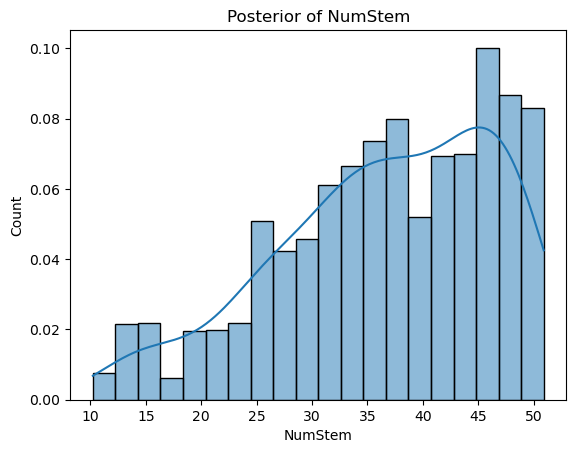

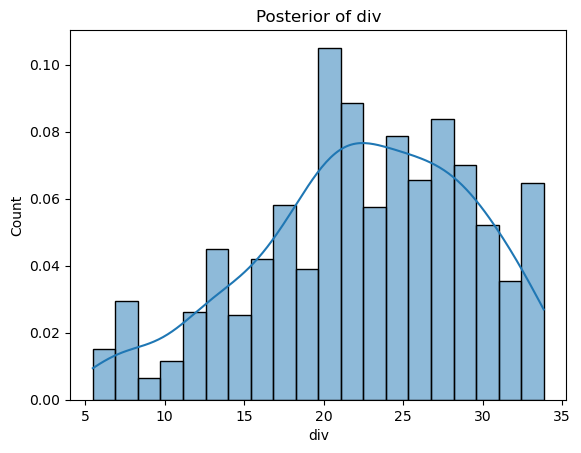

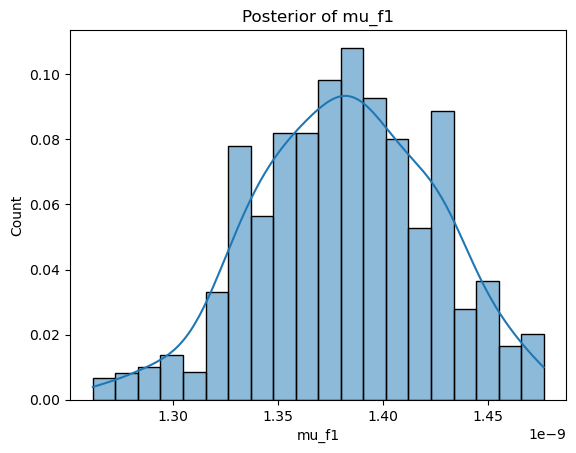

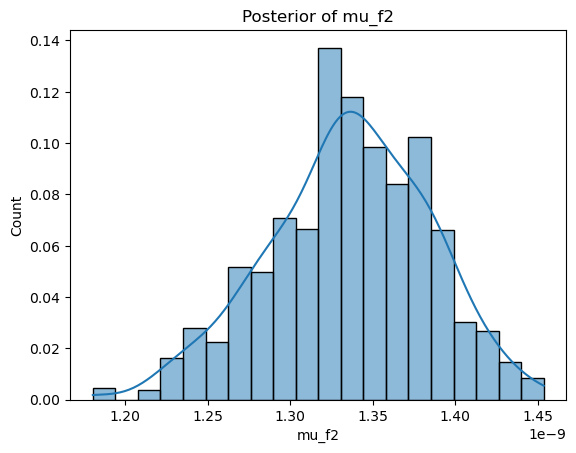

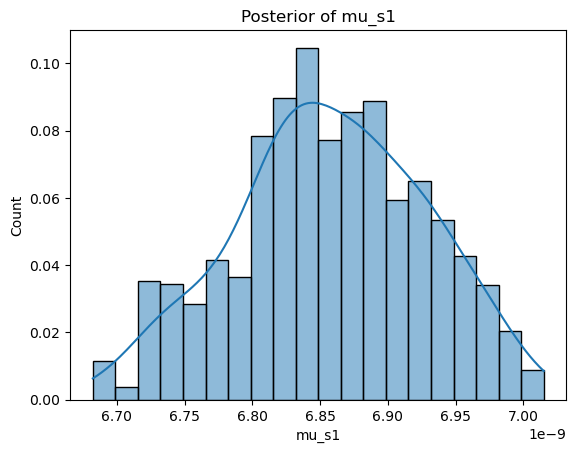

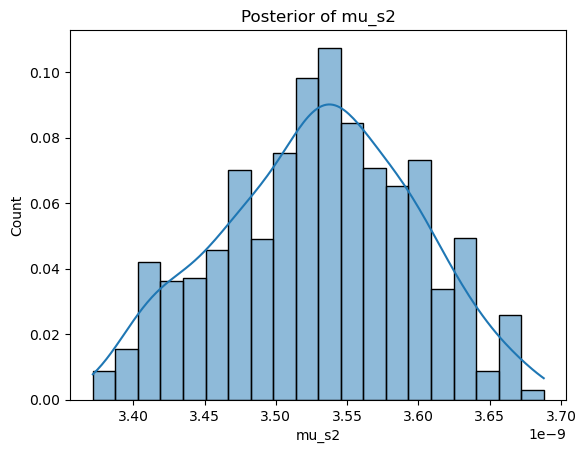

In [136]:
# Loading histroy
h = pyabc.History(f"sqlite:///abc_run_TropTree_SymBr_model{m_i}.db")

# Getting last_gene sample
latest_t = h.max_t
df, w = h.get_distribution(m=0, t=latest_t)  # or max_nr_pop-1

for col in df.columns:
    plt.figure()
    sns.histplot(data=df, x=col, weights=w, bins=20, kde=True) #, kde_kws={"cut": 0, "clip": (0, None)}) # for KDE. Ranges are restricted by cut and clip
    plt.title(f"Posterior of {col}")
    plt.xlabel(col)
    plt.show()

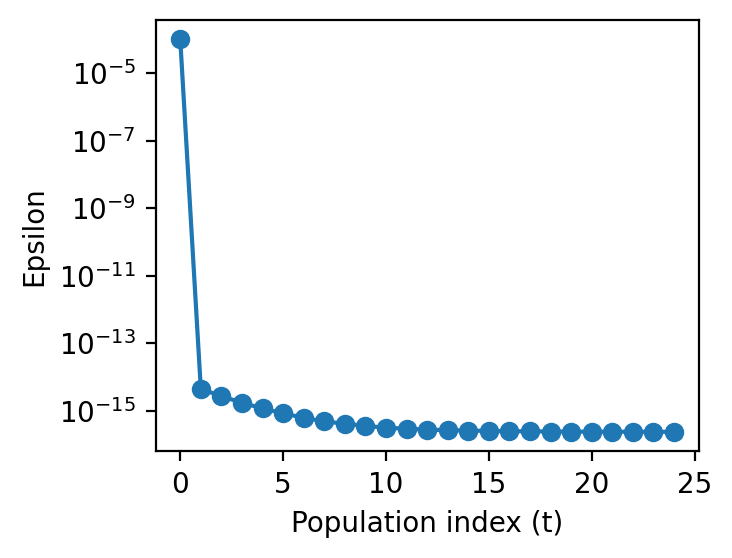

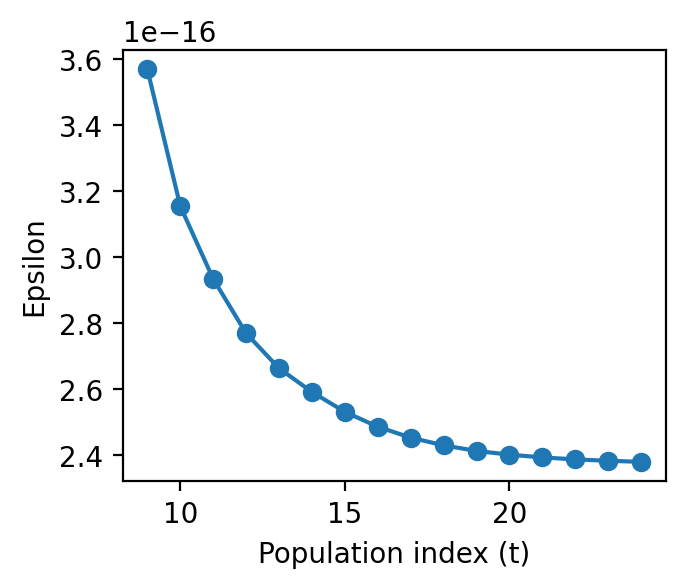

In [137]:
history_df = h.get_all_populations()

plt.figure(figsize=(3.50394, 3.50394*0.8), dpi=200)
plt.plot(history_df['t'], history_df['epsilon'], marker='o')
plt.yscale('log')
plt.xlabel("Population index (t)", size=10)
plt.ylabel("Epsilon", size=10)
# plt.title("Epsilon over populations")
plt.show()

plt.figure(figsize=(3.50394, 3.50394*0.8), dpi=200)
plt.plot(history_df['t'][10:], history_df['epsilon'][10:], marker='o')
# plt.ylim(10**-16, 10**(-15))
plt.xlabel('Population index (t)', size=10)
plt.ylabel('Epsilon', size=10)
# plt.title('Epsilon schedule')
plt.show()

 Model  4 ================================================================


<Figure size 1751.97x1751.97 with 0 Axes>

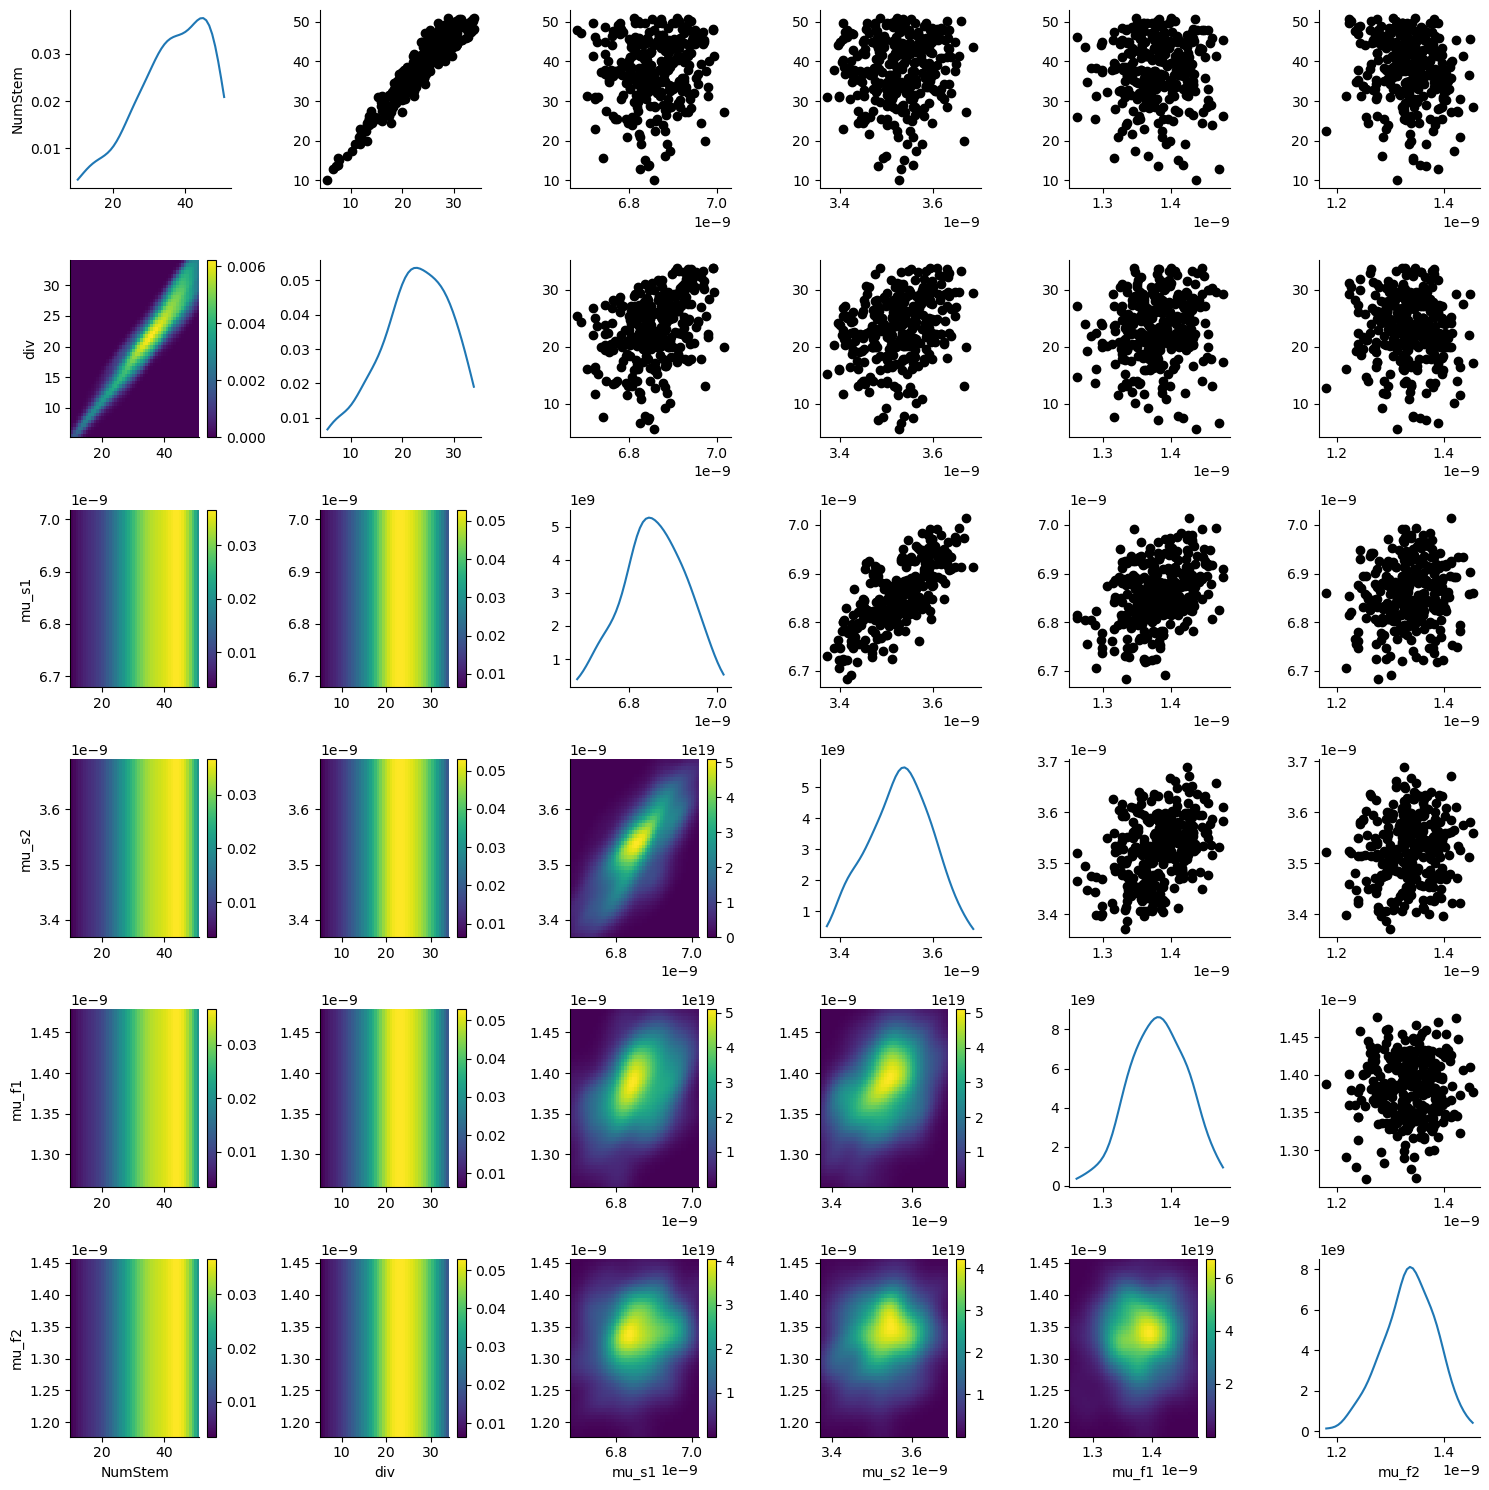

name
NumStem    1.527039e+01
div        7.800649e+00
mu_f1      1.410141e-09
mu_f2      1.341620e-09
mu_s1      6.836565e-09
mu_s2      3.539040e-09
Name: 15165, dtype: float64


In [138]:
from pyabc.visualization import plot_kde_matrix
from scipy.stats import gaussian_kde

h = pyabc.History(f"sqlite:///abc_run_TropTree_SymBr_model{m_i}.db")
param_order = ["NumStem", "div", "mu_s1", "mu_s2", "mu_f1", "mu_f2"]

plt.figure(figsize=(3.50394*2, 3.50394*2), dpi=250)
df, w = h.get_distribution(m=0, t=max_nr_pop-1)

if len(df)>0:
    print(" Model ", m_i, "=="*32)

df_ordered = df[param_order]
plot_kde_matrix(df_ordered, w) #, limits=limits)
plt.show()

kde = gaussian_kde(df.T, weights=w)
mode_params = df.iloc[np.argmax(kde(df.T))]  # Sample closest to MAP
print(mode_params)

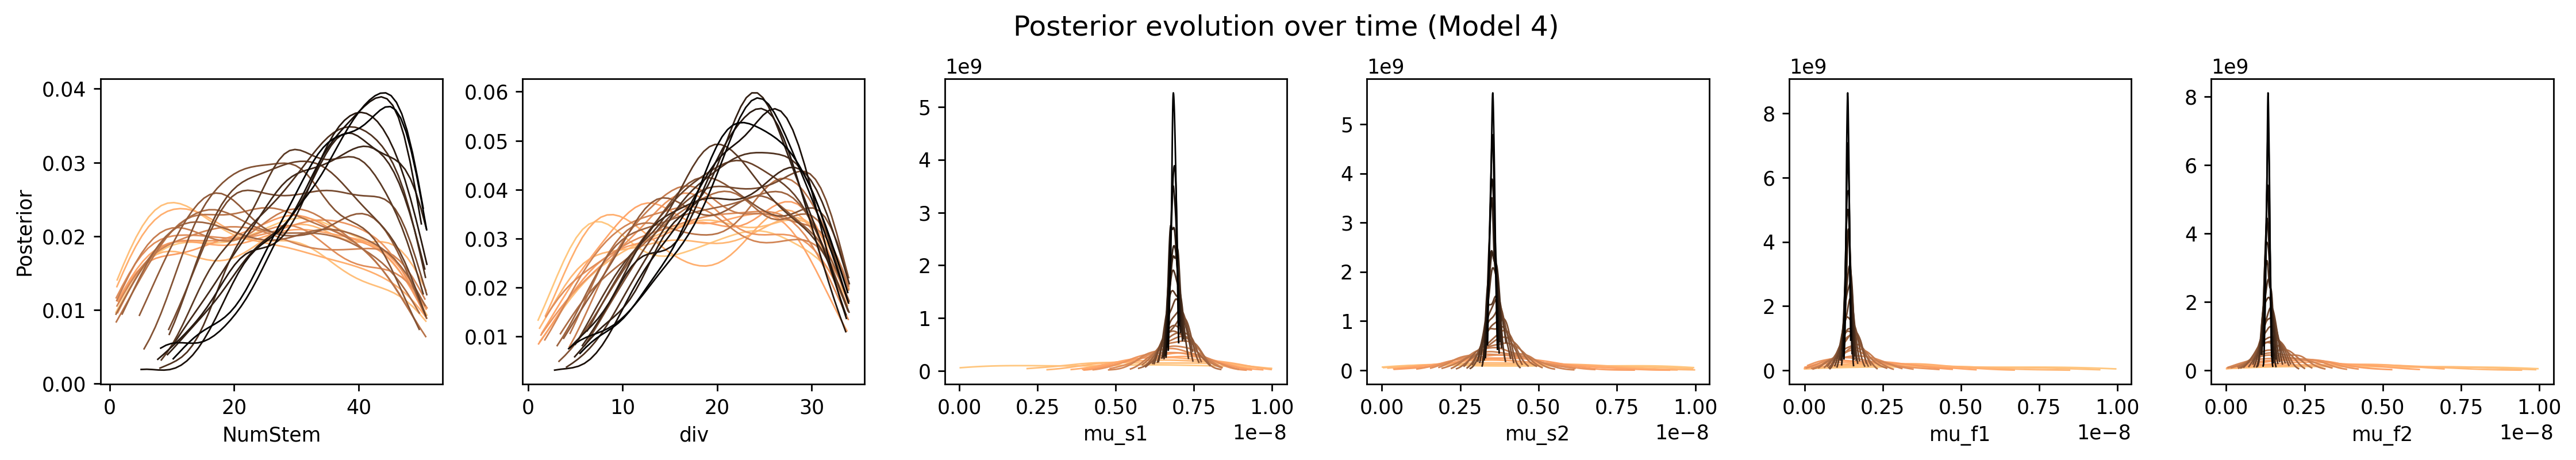

=== MAP estimates (Model 4, t=25) ===
NumStem : 4.5032e+01
div    : 2.2471e+01
mu_f1  : 1.3820e-09
mu_f2  : 1.3364e-09
mu_s1  : 6.8444e-09
mu_s2  : 3.5377e-09


In [139]:
param_order = ["NumStem", "div", "mu_s1", "mu_s2", "mu_f1", "mu_f2"]

df, w = h.get_distribution(m=0, t=max_nr_pop-1)
param_list = df.columns
    
# ----- Plotting -----
fig, axes = plt.subplots(1, len(param_list), figsize=(18, 3), dpi=250)
cmap = cm.copper

for i, param in enumerate(param_order): #param_list):
    ax = axes[i]
    for t in range(h.max_t + 1):
        df, w = h.get_distribution(m=0, t=t)
        pyabc.visualization.plot_kde_1d(
            df,
            w,
            x=param,
            xname=param,
            ax=ax,
            label=f"t={t}", # non displayed
            c=cmap(1 - t/h.max_t),
            lw = 0.8
        )
        
    if i != 0:
        ax.set_ylabel("")

plt.tight_layout()
plt.suptitle(f"Posterior evolution over time (Model {m_i})", y=1.05, fontsize=14)
plt.show()

# ----- MAP estimates -----
map_values = {}
for param in param_list:
    kde = gaussian_kde(df[param], weights=w)
    x_grid = np.linspace(df[param].min(), df[param].max(), 500)
    y_grid = kde.evaluate(x_grid)
    map_values[param] = x_grid[np.argmax(y_grid)]

# Print
print(f"=== MAP estimates (Model {m_i}, t={h.max_t+1}) ===")
for k, v in map_values.items():
    print(f"{k:6s} : {v:.4e}")

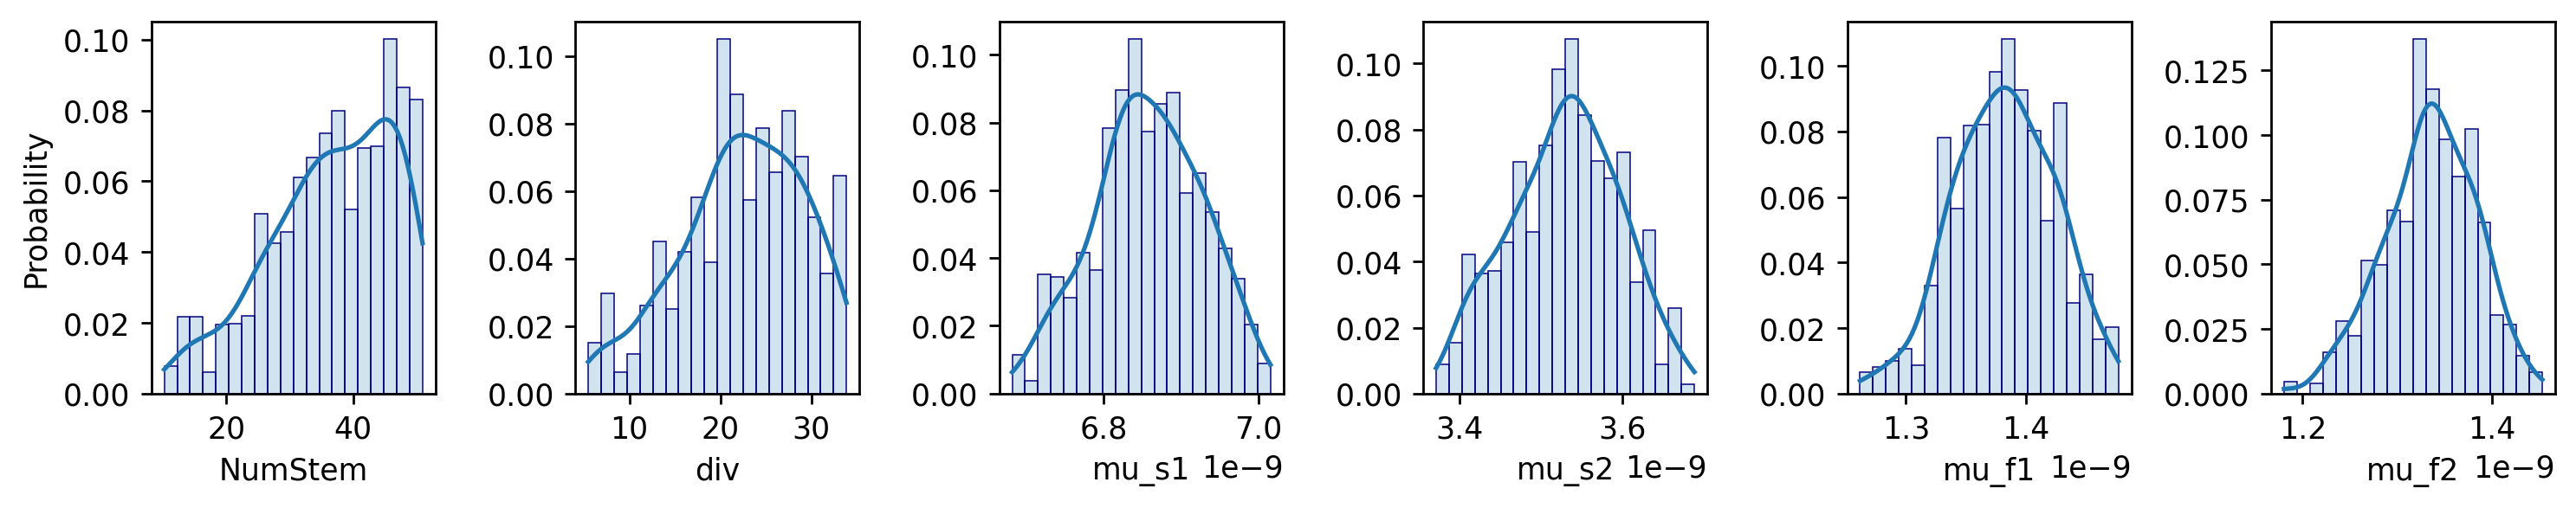

In [140]:
# Getting last gene sample
latest_t = h.max_t
df, w = h.get_distribution(m=0, t=latest_t)  # or max_nr_pop-1
param_list = df.columns

fig, axes = plt.subplots(1, len(param_list), figsize=(12, 2.5), dpi=250)
for i, param in enumerate(param_order):
    ax = axes[i]
    sns.histplot(data=df, x=param, weights=w, bins=20, alpha=.2, edgecolor='navy', kde=True, 
                 ax=ax)
    ax.set_xlabel(param)

    if i == 0:
        ax.set_ylabel("Probability", )
    else:
        ax.set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Analysis of results

### Mutation rate comparison

In [12]:
mut_rates_da = {'mu_s1':7.08e-09, 'mu_s2':4.27e-09, 'mu_f1':1.77e-09, 'mu_f2':1.29e-09} # S1, S2, F1, F2
height_age = {'mu_s1':47.6/324.9, 'mu_s2':36.2/187, 'mu_f1':39.9/78.8, 'mu_f2':38.4/54.1}
colordict = {'mu_s1':'steelblue', 'mu_s2':'skyblue', 'mu_f1':'red', 'mu_f2':'orange'}

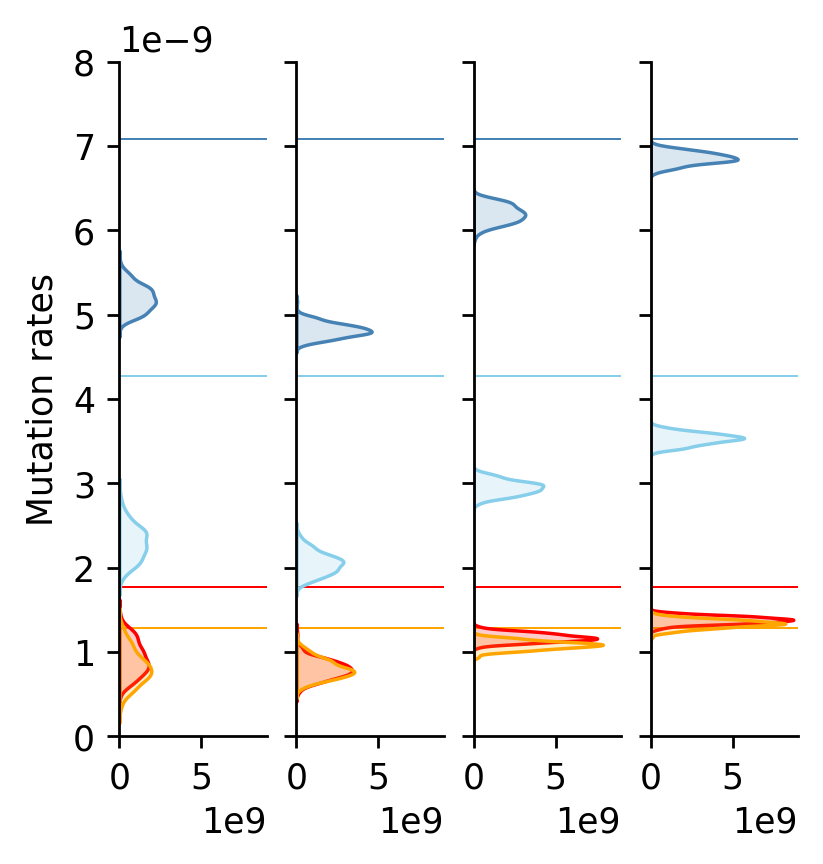

In [15]:
# Per meter mutation rates
fig, axes = plt.subplots(1, 4, figsize=(3.50394, 3.50394), dpi=250)

for m_i in [0,1,2,3]:
    
    h = pyabc.History(f"sqlite:///abc_run_TropTree_SymBr_model{m_i+1}.db")
    
    # Get last gen. samples
    latest_t = h.max_t
    df, w = h.get_distribution(m=0, t=latest_t)  # or max_nr_pop-1
    
    # Plotting
    for param in ["mu_s1", "mu_s2", "mu_f1", "mu_f2"]:
        
        sns.kdeplot(
            data=df, weights=w, y=param,
            # ax=axes,
            ax=axes[m_i],
            linewidth=1,
            fill=True,
            alpha=0.2,
            color=colordict[param]
        )
        for key in mut_rates_da.keys():
            axes[m_i].plot([0,9*10**9], [mut_rates_da[key],mut_rates_da[key]], 
                           c=colordict[key], lw=0.5, zorder=-1)
        
    axes[m_i].set_ylim(0, 8*10**(-9))
    axes[m_i].set_xlim(0, 9*10**9)
    axes[m_i].set_ylabel(""); axes[m_i].set_xlabel("")
    if m_i > 0:
        axes[m_i].tick_params(axis='y', labelleft=False)

    axes[m_i].spines['right'].set_visible(False) # elinmination of frame lines
    axes[m_i].spines['top'].set_visible(False) #
   
axes[0].set_ylabel("Mutation rates")
# axes[2].set_xlabel("Density")

plt.show()